# Backtest: S/R Confluence H1 + M15 + MACD

**Konsep Signal Kuat (Confluence):**
```
H1 S/R Level  → patokan level support/resistance dari 1000 candle H1
M15 S/R Level → konfirmasi level dari 200 candle M15  
MACD M15      → arah momentum searah signal
EMA50 H1      → filter trend utama

STRONG BUY  = harga di dekat S/R H1 (support) 
            + harga di dekat S/R M15 (support)
            + MACD M15 cross UP
            + EMA50 H1 trend UP

STRONG SELL = harga di dekat S/R H1 (resistance)
            + harga di dekat S/R M15 (resistance)
            + MACD M15 cross DOWN
            + EMA50 H1 trend DOWN
```
Makin banyak confluence = signal makin kuat.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────────────────────
CSV = '../../app/ai/candle_ai/EURUSD.m_M15_202112160545_202603251830.csv'
df_raw = pd.read_csv(CSV, sep='\t')
df_raw.columns = [c.strip('<>').lower() for c in df_raw.columns]
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.set_index('datetime').sort_index()
df_raw = df_raw[['open','high','low','close','tickvol']].rename(columns={'tickvol':'volume'})

print(f'Data M15 : {len(df_raw):,} candles')
print(f'Range    : {df_raw.index[0]} -> {df_raw.index[-1]}')

Data M15 : 100,267 candles
Range    : 2021-12-16 05:45:00 -> 2026-03-25 18:30:00


In [2]:
# ── Helper Functions ───────────────────────────────────────────────────────
def ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

def calc_atr(df, period=14):
    h, l, c = df['high'], df['low'], df['close']
    tr = pd.concat([
        h - l,
        (h - c.shift()).abs(),
        (l - c.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(span=period, adjust=False).mean()

def calc_macd(series, fast=12, slow=26, signal=9):
    macd_line = series.ewm(span=fast, adjust=False).mean() - series.ewm(span=slow, adjust=False).mean()
    sig_line  = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, sig_line

def swing_highs(high_arr, window=3):
    """Index dari swing high — high lebih tinggi dari window candle kiri & kanan."""
    result = []
    for i in range(window, len(high_arr) - window):
        if high_arr[i] == max(high_arr[i-window:i+window+1]):
            result.append(i)
    return result

def swing_lows(low_arr, window=3):
    """Index dari swing low — low lebih rendah dari window candle kiri & kanan."""
    result = []
    for i in range(window, len(low_arr) - window):
        if low_arr[i] == min(low_arr[i-window:i+window+1]):
            result.append(i)
    return result

print('Helper functions siap')

Helper functions siap


In [3]:
# ── Buat H1 Data ───────────────────────────────────────────────────────────
df_h1 = df_raw.resample('1h').agg({
    'open':  'first',
    'high':  'max',
    'low':   'min',
    'close': 'last',
}).dropna()

df_h1['ema50']  = ema(df_h1['close'], 50)
df_h1['trend']  = np.where(df_h1['ema50'].diff() > 0, 'up', 'down')
df_h1['atr_h1'] = calc_atr(df_h1, 14)

print(f'H1 candles: {len(df_h1):,}')
print(f'H1 trend  : {df_h1["trend"].value_counts().to_dict()}')

H1 candles: 26,563
H1 trend  : {'down': 13447, 'up': 13116}


In [4]:
# ── S/R dari H1 (1000 candle lookback) ────────────────────────────────────
#
# Untuk setiap candle M15, lihat 1000 candle H1 terakhir
# Ambil semua swing high & swing low → itu level S/R H1
# Cek apakah harga M15 sekarang dekat level tersebut
#
H1_LOOKBACK  = 1000   # candle H1 history untuk cari S/R
H1_SW_WINDOW = 5      # swing window H1 (lebih besar = level lebih signifikan)
H1_PROXIMITY = 2.0    # dalam 2x ATR H1 dianggap 'dekat' level S/R

h1_high  = df_h1['high'].values
h1_low   = df_h1['low'].values
h1_close = df_h1['close'].values
h1_atr   = df_h1['atr_h1'].values
h1_index = df_h1.index

# Pre-compute semua swing H1
sh_idx_h1 = set(swing_highs(h1_high, H1_SW_WINDOW))
sl_idx_h1 = set(swing_lows(h1_low,   H1_SW_WINDOW))

print(f'Swing highs H1: {len(sh_idx_h1)}')
print(f'Swing lows  H1: {len(sl_idx_h1)}')

Swing highs H1: 1797
Swing lows  H1: 1742


In [5]:
# ── S/R dari M15 (200 candle lookback) ────────────────────────────────────
M15_LOOKBACK  = 200
M15_SW_WINDOW = 3
M15_PROXIMITY = 1.5   # dalam 1.5x ATR M15

df_m15 = df_raw.copy()
df_m15['atr']      = calc_atr(df_m15, 14)
df_m15['macd'], df_m15['macd_sig'] = calc_macd(df_m15['close'])

# Reindex H1 data ke M15
df_m15['ema50_h1'] = df_h1['ema50'].reindex(df_m15.index, method='ffill')
df_m15['trend_h1'] = df_h1['trend'].reindex(df_m15.index, method='ffill')
df_m15['atr_h1']   = df_h1['atr_h1'].reindex(df_m15.index, method='ffill')

m15_high  = df_m15['high'].values
m15_low   = df_m15['low'].values
m15_close = df_m15['close'].values
m15_atr   = df_m15['atr'].values

# Pre-compute swing M15
sh_idx_m15 = set(swing_highs(m15_high, M15_SW_WINDOW))
sl_idx_m15 = set(swing_lows(m15_low,   M15_SW_WINDOW))

print(f'Swing highs M15: {len(sh_idx_m15)}')
print(f'Swing lows  M15: {len(sl_idx_m15)}')
print(f'M15 candles    : {len(df_m15):,}')

Swing highs M15: 10259
Swing lows  M15: 10195
M15 candles    : 100,267


In [6]:
# ── Generate Signal dengan Confluence ─────────────────────────────────────
#
# Confluence score per candle:
#   +1 H1 trend UP/DOWN searah signal
#   +1 harga dekat S/R H1 (support=buy, resistance=sell)
#   +1 harga dekat S/R M15 (support=buy, resistance=sell)
#   +1 MACD cross searah signal
#
# Signal KUAT = confluence >= 3 (minimal 3/4)
# Signal TERKUAT = confluence == 4 (semua konfirmasi)

n          = len(df_m15)
macd_arr   = df_m15['macd'].values
sig_arr    = df_m15['macd_sig'].values
trend_arr  = df_m15['trend_h1'].values
atr_arr    = df_m15['atr'].values
atr_h1_arr = df_m15['atr_h1'].values
h1_idx_map = {t: i for i, t in enumerate(h1_index)}

ATR_MIN = 0.0008  # minimal 8 pips

confluence_score = np.zeros(n, dtype=int)
signal_arr       = np.full(n, 'hold', dtype=object)
direction_arr    = np.full(n, '', dtype=object)

# MACD crossover
macd_cross_up   = np.zeros(n, dtype=bool)
macd_cross_down = np.zeros(n, dtype=bool)
for i in range(1, n):
    if macd_arr[i-1] < sig_arr[i-1] and macd_arr[i] >= sig_arr[i]:
        macd_cross_up[i] = True
    elif macd_arr[i-1] > sig_arr[i-1] and macd_arr[i] <= sig_arr[i]:
        macd_cross_down[i] = True

# Cari waktu H1 yang sesuai dengan M15
m15_index = df_m15.index

for i in range(max(H1_LOOKBACK*4, M15_LOOKBACK), n):
    if atr_arr[i] < ATR_MIN:
        continue

    c         = m15_close[i]
    atr_m15   = atr_arr[i]
    atr_h1_v  = atr_h1_arr[i] if not np.isnan(atr_h1_arr[i]) else atr_m15 * 4
    trend     = trend_arr[i]

    # --- Cek S/R H1 ---
    # Cari posisi H1 saat ini
    curr_h1_time = m15_index[i].floor('1h')
    h1_pos = None
    for idx, t in enumerate(h1_index):
        if t == curr_h1_time:
            h1_pos = idx
            break

    near_h1_support    = False
    near_h1_resistance = False
    if h1_pos is not None and h1_pos >= H1_LOOKBACK:
        lookback_range = range(h1_pos - H1_LOOKBACK, h1_pos)
        thresh_h1 = H1_PROXIMITY * atr_h1_v
        for k in lookback_range:
            if k in sl_idx_h1 and abs(h1_low[k] - c) <= thresh_h1:
                near_h1_support = True
            if k in sh_idx_h1 and abs(h1_high[k] - c) <= thresh_h1:
                near_h1_resistance = True
            if near_h1_support and near_h1_resistance:
                break

    # --- Cek S/R M15 ---
    thresh_m15 = M15_PROXIMITY * atr_m15
    near_m15_support    = False
    near_m15_resistance = False
    for k in range(i - M15_LOOKBACK, i):
        if k in sl_idx_m15 and abs(m15_low[k] - c) <= thresh_m15:
            near_m15_support = True
        if k in sh_idx_m15 and abs(m15_high[k] - c) <= thresh_m15:
            near_m15_resistance = True
        if near_m15_support and near_m15_resistance:
            break

    # --- Hitung Confluence BUY ---
    if macd_cross_up[i]:
        score = 0
        if trend == 'up':           score += 1  # H1 trend searah
        if near_h1_support:         score += 1  # dekat support H1
        if near_m15_support:        score += 1  # dekat support M15
        if macd_cross_up[i]:        score += 1  # MACD cross up
        if score >= 3:
            confluence_score[i] = score
            signal_arr[i]       = 'buy'

    # --- Hitung Confluence SELL ---
    elif macd_cross_down[i]:
        score = 0
        if trend == 'down':         score += 1  # H1 trend searah
        if near_h1_resistance:      score += 1  # dekat resistance H1
        if near_m15_resistance:     score += 1  # dekat resistance M15
        if macd_cross_down[i]:      score += 1  # MACD cross down
        if score >= 3:
            confluence_score[i] = score
            signal_arr[i]       = 'sell'

df_m15['signal']     = signal_arr
df_m15['confluence'] = confluence_score

sig_counts = pd.Series(signal_arr).value_counts()
print('=== Distribusi Signal ===')
print(sig_counts)
print(f'\nConfluence 3 : {(confluence_score == 3).sum()}')
print(f'Confluence 4 : {(confluence_score == 4).sum()}  ← signal terkuat')

=== Distribusi Signal ===
hold    97738
buy      1287
sell     1242
Name: count, dtype: int64

Confluence 3 : 1593
Confluence 4 : 936  ← signal terkuat


In [7]:
# ── Backtest Engine ────────────────────────────────────────────────────────
def run_backtest(df, rr_mult=1.5, min_confluence=3, max_candle=16):
    close_arr  = df['close'].values
    high_arr   = df['high'].values
    low_arr    = df['low'].values
    atr_arr    = df['atr'].values
    sig_arr    = df['signal'].values
    conf_arr   = df['confluence'].values
    n          = len(df)

    trades = []
    i = 0
    while i < n:
        if sig_arr[i] not in ('buy', 'sell') or conf_arr[i] < min_confluence:
            i += 1
            continue

        direction  = sig_arr[i]
        entry      = close_arr[i]
        atr_val    = atr_arr[i]
        sl_dist    = 1.0     * atr_val
        tp_dist    = rr_mult * atr_val

        sl = entry - sl_dist if direction == 'buy' else entry + sl_dist
        tp = entry + tp_dist if direction == 'buy' else entry - tp_dist

        outcome    = 'timeout'
        exit_price = entry
        for j in range(i+1, min(i+1+max_candle, n)):
            if direction == 'buy':
                if low_arr[j]  <= sl: outcome = 'loss'; exit_price = sl; break
                if high_arr[j] >= tp: outcome = 'win';  exit_price = tp; break
            else:
                if high_arr[j] >= sl: outcome = 'loss'; exit_price = sl; break
                if low_arr[j]  <= tp: outcome = 'win';  exit_price = tp; break

        pips = (exit_price - entry) * 10000 if direction == 'buy' else (entry - exit_price) * 10000

        trades.append({
            'datetime':   df.index[i],
            'direction':  direction,
            'confluence': int(conf_arr[i]),
            'entry':      round(entry, 5),
            'sl':         round(sl, 5),
            'tp':         round(tp, 5),
            'exit_price': round(exit_price, 5),
            'outcome':    outcome,
            'pips':       round(pips, 1),
            'atr':        round(atr_val, 5),
        })
        i += max_candle + 1

    return pd.DataFrame(trades)


# Jalankan 3 skenario
t_c3_rr15 = run_backtest(df_m15, rr_mult=1.5, min_confluence=3)
t_c3_rr20 = run_backtest(df_m15, rr_mult=2.0, min_confluence=3)
t_c4_rr15 = run_backtest(df_m15, rr_mult=1.5, min_confluence=4)  # signal terkuat

print(f'Confluence>=3, RR 1:1.5 → {len(t_c3_rr15)} trades')
print(f'Confluence>=3, RR 1:2.0 → {len(t_c3_rr20)} trades')
print(f'Confluence==4, RR 1:1.5 → {len(t_c4_rr15)} trades  ← signal terkuat')

Confluence>=3, RR 1:1.5 → 1465 trades
Confluence>=3, RR 1:2.0 → 1465 trades
Confluence==4, RR 1:1.5 → 693 trades  ← signal terkuat


In [8]:
# ── Analisis Hasil ─────────────────────────────────────────────────────────
def analyze(trades, label, modal=100, lot=0.01):
    if len(trades) == 0:
        print(f'{label}: tidak ada trade')
        return trades

    wins    = (trades['outcome'] == 'win').sum()
    losses  = (trades['outcome'] == 'loss').sum()
    timeout = (trades['outcome'] == 'timeout').sum()
    total   = len(trades)
    wr      = wins / total * 100

    avg_win  = trades.loc[trades['outcome'] == 'win',  'pips'].mean() or 0
    avg_loss = trades.loc[trades['outcome'] == 'loss', 'pips'].mean() or 0
    total_pips = trades['pips'].sum()

    gp = trades.loc[trades['pips'] > 0, 'pips'].sum()
    gl = abs(trades.loc[trades['pips'] < 0, 'pips'].sum())
    pf = gp / gl if gl > 0 else float('inf')

    pip_val  = lot * 10
    trades   = trades.copy()
    trades['usd']    = trades['pips'] * pip_val
    trades['equity'] = modal + trades['usd'].cumsum()
    max_dd   = (trades['equity'].cummax() - trades['equity']).max()

    print(f'{'='*54}')
    print(f'  {label}')
    print(f'{'='*54}')
    print(f'  Total Trade  : {total}  (~{total//48:.0f}/bulan)')
    print(f'  Win          : {wins}  ({wr:.1f}%)')
    print(f'  Loss         : {losses}  ({losses/total*100:.1f}%)')
    print(f'  Timeout      : {timeout}  ({timeout/total*100:.1f}%)')
    print(f'  Avg Win      : +{avg_win:.1f} pips')
    print(f'  Avg Loss     : {avg_loss:.1f} pips')
    print(f'  Profit Factor: {pf:.2f}')
    print(f'  Total Pips   : {total_pips:+.1f}')
    print(f'  Total USD    : ${total_pips*pip_val:+.2f}  (modal ${modal}, lot {lot})')
    print(f'  Max Drawdown : ${max_dd:.2f}')
    print(f'  Equity Akhir : ${trades["equity"].iloc[-1]:.2f}')
    print(f'{'='*54}')
    return trades

t_c3_rr15 = analyze(t_c3_rr15, 'Confluence>=3 | RR 1:1.5 | H1+M15 S/R + MACD')
print()
t_c3_rr20 = analyze(t_c3_rr20, 'Confluence>=3 | RR 1:2.0 | H1+M15 S/R + MACD')
print()
t_c4_rr15 = analyze(t_c4_rr15, 'Confluence==4 | RR 1:1.5 | SIGNAL TERKUAT')

  Confluence>=3 | RR 1:1.5 | H1+M15 S/R + MACD
  Total Trade  : 1465  (~30/bulan)
  Win          : 521  (35.6%)
  Loss         : 805  (54.9%)
  Timeout      : 139  (9.5%)
  Avg Win      : +16.9 pips
  Avg Loss     : -11.2 pips
  Profit Factor: 0.98
  Total Pips   : -217.5
  Total USD    : $-21.75  (modal $100, lot 0.01)
  Max Drawdown : $91.51
  Equity Akhir : $78.25

  Confluence>=3 | RR 1:2.0 | H1+M15 S/R + MACD
  Total Trade  : 1465  (~30/bulan)
  Win          : 398  (27.2%)
  Loss         : 856  (58.4%)
  Timeout      : 211  (14.4%)
  Avg Win      : +22.3 pips
  Avg Loss     : -11.2 pips
  Profit Factor: 0.92
  Total Pips   : -727.9
  Total USD    : $-72.79  (modal $100, lot 0.01)
  Max Drawdown : $93.66
  Equity Akhir : $27.21

  Confluence==4 | RR 1:1.5 | SIGNAL TERKUAT
  Total Trade  : 693  (~14/bulan)
  Win          : 274  (39.5%)
  Loss         : 351  (50.6%)
  Timeout      : 68  (9.8%)
  Avg Win      : +16.7 pips
  Avg Loss     : -11.3 pips
  Profit Factor: 1.16
  Total Pips 

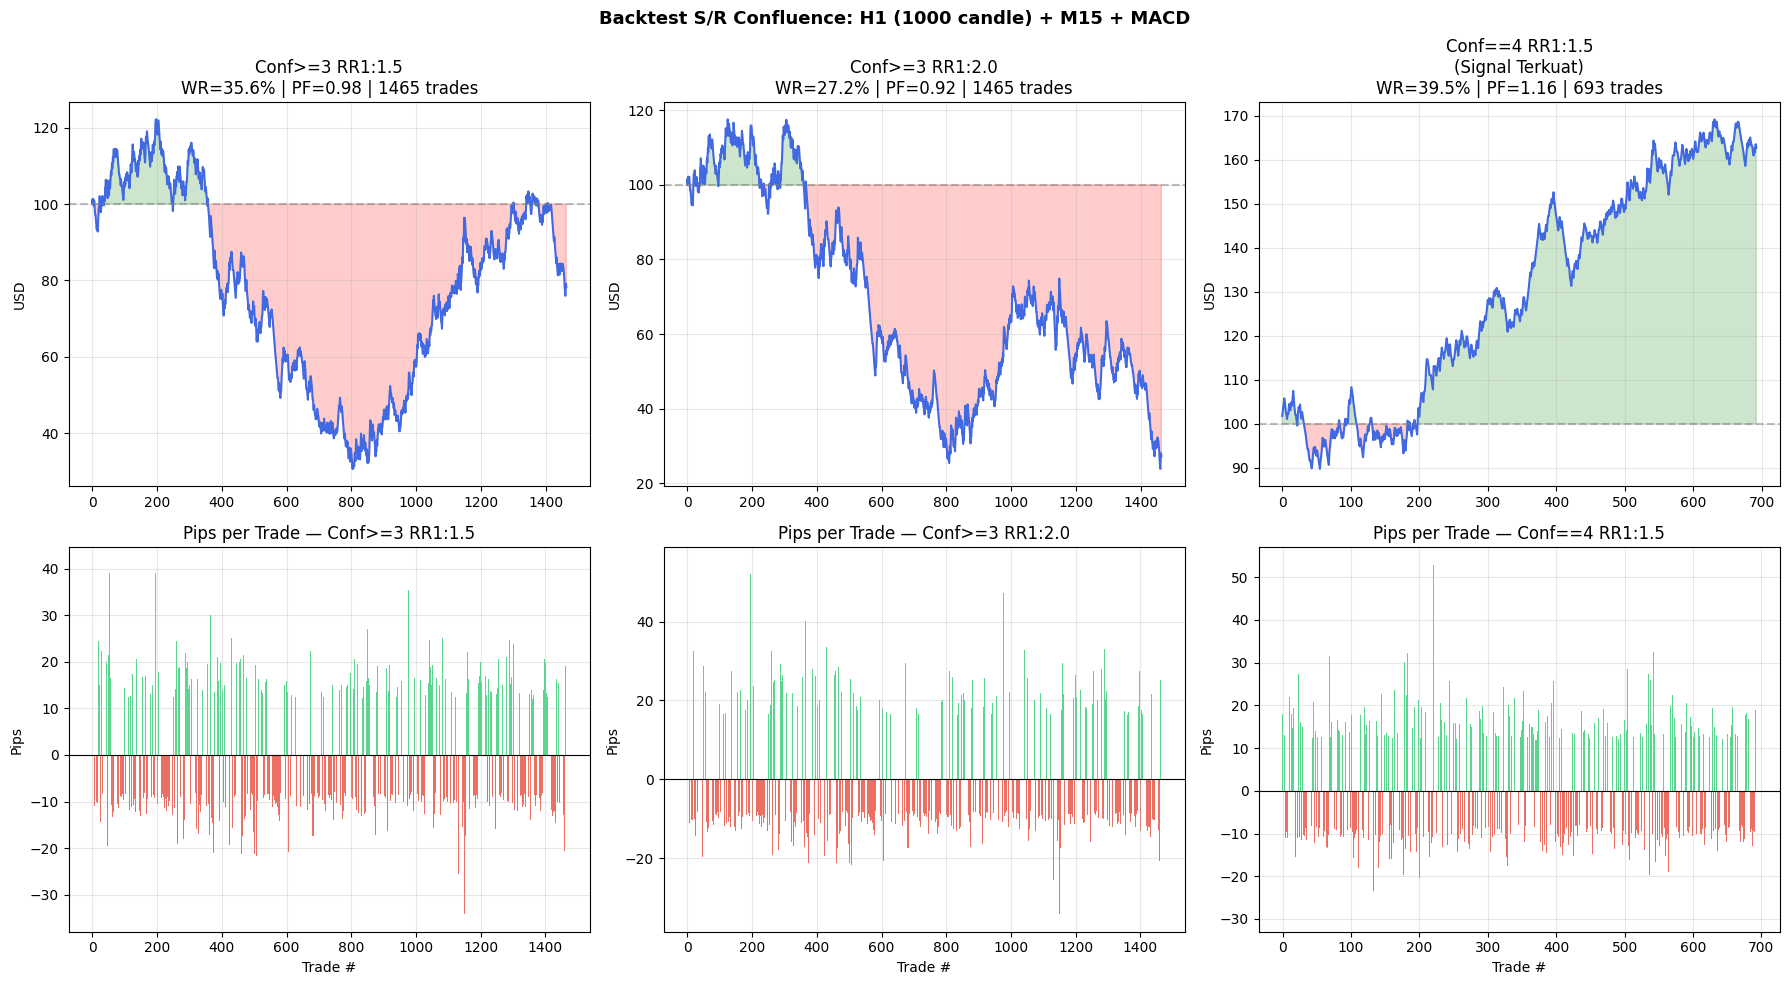

Chart disimpan: backtest_sr_confluence_result.png


In [9]:
# ── Visualisasi ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Backtest S/R Confluence: H1 (1000 candle) + M15 + MACD', fontsize=13, fontweight='bold')

scenarios = [
    (t_c3_rr15, 'Conf>=3 RR1:1.5'),
    (t_c3_rr20, 'Conf>=3 RR1:2.0'),
    (t_c4_rr15, 'Conf==4 RR1:1.5\n(Signal Terkuat)'),
]

for col, (trades, label) in enumerate(scenarios):
    if trades is None or len(trades) == 0:
        continue

    # Equity curve
    ax = axes[0, col]
    ax.plot(range(len(trades)), trades['equity'], color='royalblue', linewidth=1.5)
    ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Modal awal')
    ax.fill_between(range(len(trades)), trades['equity'], 100,
                    where=trades['equity'] >= 100, alpha=0.2, color='green')
    ax.fill_between(range(len(trades)), trades['equity'], 100,
                    where=trades['equity'] < 100, alpha=0.2, color='red')
    wr = (trades['outcome'] == 'win').mean() * 100
    pf_val = trades.loc[trades['pips']>0,'pips'].sum() / abs(trades.loc[trades['pips']<0,'pips'].sum() or 1)
    ax.set_title(f'{label}\nWR={wr:.1f}% | PF={pf_val:.2f} | {len(trades)} trades')
    ax.set_ylabel('USD')
    ax.grid(True, alpha=0.3)

    # Win/Loss bar per trade
    ax = axes[1, col]
    colors = ['#2ecc71' if p > 0 else ('#e74c3c' if p < 0 else '#f39c12') for p in trades['pips']]
    ax.bar(range(len(trades)), trades['pips'], color=colors, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Pips per Trade — {label.split(chr(10))[0]}')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Pips')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('backtest_sr_confluence_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart disimpan: backtest_sr_confluence_result.png')

In [10]:
# ── Detail Signal Terkuat (Confluence 4) ──────────────────────────────────
if len(t_c4_rr15) > 0:
    print('=== Detail Trade Confluence 4 (Signal Terkuat) ===')
    print(t_c4_rr15[['datetime','direction','confluence','entry','sl','tp','outcome','pips']].to_string(index=False))

    print('\n=== Win Rate per Arah ===')
    for d in ['buy','sell']:
        t = t_c4_rr15[t_c4_rr15['direction'] == d]
        if len(t) == 0: continue
        wr = (t['outcome'] == 'win').mean() * 100
        print(f'  {d.upper():4s}: {len(t):3d} trades | WR: {wr:.1f}% | Pips: {t["pips"].sum():+.1f}')

=== Detail Trade Confluence 4 (Signal Terkuat) ===
           datetime direction  confluence   entry      sl      tp outcome  pips
2022-02-14 17:15:00      sell           4 1.13038 1.13158 1.12858     win  18.0
2022-02-15 10:00:00       buy           4 1.13324 1.13237 1.13455     win  13.1
2022-02-15 16:15:00      sell           4 1.13480 1.13571 1.13343     win  13.7
2022-02-16 18:15:00       buy           4 1.13722 1.13635 1.13853     win  13.1
2022-02-17 05:45:00      sell           4 1.13363 1.13473 1.13198    loss -11.0
2022-02-17 11:00:00      sell           4 1.13432 1.13587 1.13199    loss -15.5
2022-02-17 15:15:00      sell           4 1.13617 1.13713 1.13473    loss  -9.6
2022-02-18 00:15:00      sell           4 1.13577 1.13688 1.13410    loss -11.1
2022-02-21 20:15:00      sell           4 1.13235 1.13319 1.13109     win  12.6
2022-02-25 00:00:00      sell           4 1.11924 1.12172 1.11551 timeout   0.0
2022-02-28 03:15:00      sell           4 1.11682 1.11828 1.11463    

In [11]:
# ── Simpan & Kesimpulan ────────────────────────────────────────────────────
if len(t_c3_rr15) > 0: t_c3_rr15.to_csv('sr_confluence_c3_rr15.csv', index=False)
if len(t_c4_rr15) > 0: t_c4_rr15.to_csv('sr_confluence_c4_rr15.csv', index=False)
print('Tersimpan ke CSV')

print()
print('='*54)
print('  KESIMPULAN CONFLUENCE S/R')
print('='*54)
print('  Signal kuat  = Confluence >= 3/4')
print('  Signal terkuat = Confluence 4/4:')
print('    ✓ EMA50 H1 trend searah')
print('    ✓ Harga dekat S/R dari 1000 candle H1')
print('    ✓ Harga dekat S/R dari 200 candle M15')
print('    ✓ MACD M15 cross searah signal')
print('='*54)

Tersimpan ke CSV

  KESIMPULAN CONFLUENCE S/R
  Signal kuat  = Confluence >= 3/4
  Signal terkuat = Confluence 4/4:
    ✓ EMA50 H1 trend searah
    ✓ Harga dekat S/R dari 1000 candle H1
    ✓ Harga dekat S/R dari 200 candle M15
    ✓ MACD M15 cross searah signal
